# 📋 Notebook 2: Survey Dataset Cleaning

This notebook covers all cleaning and preprocessing steps for the **`survey.csv`** — the demographics and lifestyle dataset collected from 5,027 Amazon users via an online Qualtrics survey.

**Input:** `survey.csv` (raw dataset from Harvard Dataverse)  
**Output:** `cleaned_survey_dataset.csv` — fully cleaned, ready for merging in Notebook 3

**Sections:**
1. Importing libraries
2. Loading the survey dataset
3. Pre-processing (rename, missing values, duplicates)
4. Save cleaned dataset
5. Exploratory visualisations

---

## 1. Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Loading the Survey Dataset

We load `survey.csv` — the raw demographics and lifestyle data for 5,027 participants.

> ⚠️ **Update `file_path2` to your own local directory before running.**

**About this dataset:**
- Each row = one unique survey respondent
- 23 columns covering demographics (`Age`, `Race`, `Gender`, `Income`, `Education`), lifestyle (`Alcohol`, `Cigarettes`, `Marijuana`, `Diabetes`), household info (`Family Size`, `No. of Users`), and data privacy attitudes (`Sell_Data`, `Research`, etc.)
- The `Survey ResponseID` column links each user to their purchases

In [2]:
file_path2 = "C://Users//vaish//Desktop//MKT 4990//Datasets//survey.csv"
users = pd.read_csv(file_path2)

## 3. Pre-processing
### 3.1 Preview the Raw Survey Data

`.head()` gives a first look at the data. Column names at this stage are raw **Qualtrics question IDs** (e.g., `Q-demos-age`, `Q-demos-race`) — not human-readable. These will be renamed in Section 4.

In [3]:
users.head()

,Survey ResponseID,Q-demos-age,Q-demos-hispanic,Q-demos-race,Q-demos-education,Q-demos-income,Q-demos-gender,Q-sexual-orientation,Q-demos-state,Q-amazon-use-howmany,...,Q-substance-use-marijuana,Q-substance-use-alcohol,Q-personal-diabetes,Q-personal-wheelchair,Q-life-changes,Q-sell-YOUR-data,Q-sell-consumer-data,Q-small-biz-use,Q-census-use,Q-research-society
0,R_1ou69fj4DQGsVcp,35 - 44 years,No,Black or African American,High school diploma or GED,"$25,000 - $49,999",Female,heterosexual (straight),Iowa,2,...,No,Yes,No,No,Lost a job,No,No,No,No,No
1,R_2UbJL30HRjK1sdD,45 - 54 years,No,White or Caucasian,High school diploma or GED,"$100,000 - $149,999",Male,heterosexual (straight),Ohio,2,...,No,No,No,No,NaN,No,No,No,No,Yes
2,R_UPXamGKtmf4RVIZ,25 - 34 years,No,White or Caucasian,High school diploma or GED,"$25,000 - $49,999",Male,heterosexual (straight),Arkansas,1 (just me!),...,No,No,Yes,No,NaN,No,No,No,No,Yes
3,R_2dYk5auG9Fv5Qve,35 - 44 years,Yes,White or Caucasian,"Graduate or professional degree (MA, MS, MBA, ...","$50,000 - $74,999",Male,heterosexual (straight),Tennessee,1 (just me!),...,No,No,No,No,NaN,No,No,No,No,No
4,R_2aP0GyIR66gSTiR,25 - 34 years,No,White or Caucasian,High school diploma or GED,"$50,000 - $74,999",Male,heterosexual (straight),Virginia,2,...,No,Yes,No,No,NaN,No,Yes if consumers get part of the profit,I don't know,No,No


### 3.2. View Raw Column Names

`.columns` shows all 23 original Qualtrics-generated column names. Keep this as a reference for tracing any renamed column back to its original survey question ID.

In [4]:
users.columns

Index(['Survey ResponseID', 'Q-demos-age', 'Q-demos-hispanic', 'Q-demos-race',
       'Q-demos-education', 'Q-demos-income', 'Q-demos-gender',
       'Q-sexual-orientation', 'Q-demos-state', 'Q-amazon-use-howmany',
       'Q-amazon-use-hh-size', 'Q-amazon-use-how-oft',
       'Q-substance-use-cigarettes', 'Q-substance-use-marijuana',
       'Q-substance-use-alcohol', 'Q-personal-diabetes',
       'Q-personal-wheelchair', 'Q-life-changes', 'Q-sell-YOUR-data',
       'Q-sell-consumer-data', 'Q-small-biz-use', 'Q-census-use',
       'Q-research-society'],
      dtype='object')

### 3.3. Rename Columns

We rename all columns from Qualtrics question codes to descriptive, readable names. The `User_ID` rename is especially critical — it must exactly match the `User_ID` column in the purchases dataset for the merge in Notebook 3 to work correctly.

| Original | Renamed |
|---|---|
| `Survey ResponseID` | `User_ID` |
| `Q-demos-age` | `Age` |
| `Q-demos-hispanic` | `Hispanic` |
| `Q-demos-race` | `Race` |
| `Q-demos-education` | `Education` |
| `Q-demos-income` | `Income` |
| `Q-demos-gender` | `Gender` |
| `Q-demos-sexual-orientation` | `Sexual_Orientation` |
| `Q-demos-state` | `State` |
| *(household fields)* | `No.of Users`, `Family Size`, `Acc Usage` |
| *(lifestyle fields)* | `Cigarettes`, `Marijuana`, `Alcohol`, `Diabetes`, `Wheel_Chair`, `Life_Changes` |
| *(data privacy fields)* | `Sell_Data`, `Sell_Consumer_Data`, `Small_Business_Use`, `Census_Use`, `Research` |

In [5]:
users.rename(columns={'Survey ResponseID': 'User_ID', 'Q-demos-age':'Age','Q-demos-hispanic':'Hispanic','Q-demos-race':'Race','Q-demos-education':'Education',
                      'Q-demos-state':'State','Q-demos-income':'Income','Q-demos-gender':'Gender','Q-sexual-orientation':'Sexual_Orientation','Q-amazon-use-howmany':'No.of Users',
                      'Q-amazon-use-hh-size':'Family Size','Q-amazon-use-how-oft':'Acc Usage', 'Q-substance-use-cigarettes':'Cigarettes','Q-substance-use-marijuana':'Marijuana',
                      'Q-substance-use-alcohol':'Alcohol', 'Q-personal-diabetes':'Diabetes', 'Q-personal-wheelchair':'Wheel_Chair','Q-life-changes':'Life_Changes',
                      'Q-sell-YOUR-data':'Sell_Data','Q-sell-consumer-data':'Sell_Consumer_Data','Q-small-biz-use':'Small_Business_Use','Q-census-use':'Census_Use',
                      'Q-research-society':'Research'
                      }, inplace=True)

In [6]:
users.head()

,User_ID,Age,Hispanic,Race,Education,Income,Gender,Sexual_Orientation,State,No.of Users,...,Marijuana,Alcohol,Diabetes,Wheel_Chair,Life_Changes,Sell_Data,Sell_Consumer_Data,Small_Business_Use,Census_Use,Research
0,R_1ou69fj4DQGsVcp,35 - 44 years,No,Black or African American,High school diploma or GED,"$25,000 - $49,999",Female,heterosexual (straight),Iowa,2,...,No,Yes,No,No,Lost a job,No,No,No,No,No
1,R_2UbJL30HRjK1sdD,45 - 54 years,No,White or Caucasian,High school diploma or GED,"$100,000 - $149,999",Male,heterosexual (straight),Ohio,2,...,No,No,No,No,NaN,No,No,No,No,Yes
2,R_UPXamGKtmf4RVIZ,25 - 34 years,No,White or Caucasian,High school diploma or GED,"$25,000 - $49,999",Male,heterosexual (straight),Arkansas,1 (just me!),...,No,No,Yes,No,NaN,No,No,No,No,Yes
3,R_2dYk5auG9Fv5Qve,35 - 44 years,Yes,White or Caucasian,"Graduate or professional degree (MA, MS, MBA, ...","$50,000 - $74,999",Male,heterosexual (straight),Tennessee,1 (just me!),...,No,No,No,No,NaN,No,No,No,No,No
4,R_2aP0GyIR66gSTiR,25 - 34 years,No,White or Caucasian,High school diploma or GED,"$50,000 - $74,999",Male,heterosexual (straight),Virginia,2,...,No,Yes,No,No,NaN,No,Yes if consumers get part of the profit,I don't know,No,No


### 3.4. Check for Missing Values

`.isnull().sum()` across all 23 columns. Most fields are fully complete because Qualtrics required responses for all key demographic questions.

**Expected finding:** Only `Life_Changes` has missing values (~3,384 NaNs) — this was an **optional** free-text field asking about major life events, so many respondents left it blank.

In [7]:
users.isnull().sum()

User_ID                  0
Age                      0
Hispanic                 0
Race                     0
Education                0
Income                   0
Gender                   0
Sexual_Orientation       0
State                    0
No.of Users              0
Family Size              0
Acc Usage                0
Cigarettes               0
Marijuana                0
Alcohol                  0
Diabetes                 0
Wheel_Chair              0
Life_Changes          3384
Sell_Data                0
Sell_Consumer_Data       0
Small_Business_Use       0
Census_Use               0
Research                 0
dtype: int64

### 3.5. Impute Missing Values in `Life_Changes`

We fill the 3,384 missing values with `"N/A"` to indicate the respondent did not report a major life change. This is consistent with the imputation approach in Notebook 1 — preserving the row with a clearly labelled placeholder rather than dropping it.

`.isnull().sum()` confirms zero missing values remain across the entire dataset.

In [8]:
users['Life_Changes'] = users['Life_Changes'].fillna("N/A")

In [9]:
users.isnull().sum()

User_ID               0
Age                   0
Hispanic              0
Race                  0
Education             0
Income                0
Gender                0
Sexual_Orientation    0
State                 0
No.of Users           0
Family Size           0
Acc Usage             0
Cigarettes            0
Marijuana             0
Alcohol               0
Diabetes              0
Wheel_Chair           0
Life_Changes          0
Sell_Data             0
Sell_Consumer_Data    0
Small_Business_Use    0
Census_Use            0
Research              0
dtype: int64

### 3.6. Check for Duplicate Users

`.duplicated().any()` should return `False` — each participant completed the survey exactly once, so no duplicate `User_ID` entries are expected.

In [10]:
users.duplicated().any()

False

### 3.7. Unique User Count

Confirms how many unique users are in the survey dataset. This should be **5,027** — one row per respondent.

> 📌 When this is merged with purchases in Notebook 3, you will see 5,026 matched users (inner join). The 1-user difference is because one respondent completed the survey but chose not to share their purchase history — this is expected and by design.

In [11]:
users["User_ID"].nunique()

5027

## 4. Save the Cleaned Survey Dataset

Save the cleaned `users` DataFrame as `cleaned_survey_dataset.csv`. This file is loaded in Notebook 3 for merging.

> ⚠️ **Update the path to your own directory.**

In [12]:
users.to_csv(
    r"C:\Users\vaish\Desktop\MKT 4990\cleaned_survey_dataset.csv",
    index=False
)
print('Saved. Shape:', users.shape)

Saved. Shape: (5027, 23)


## 5. Exploratory visualisations
### 5.1 Age Distribution - Bar Chart

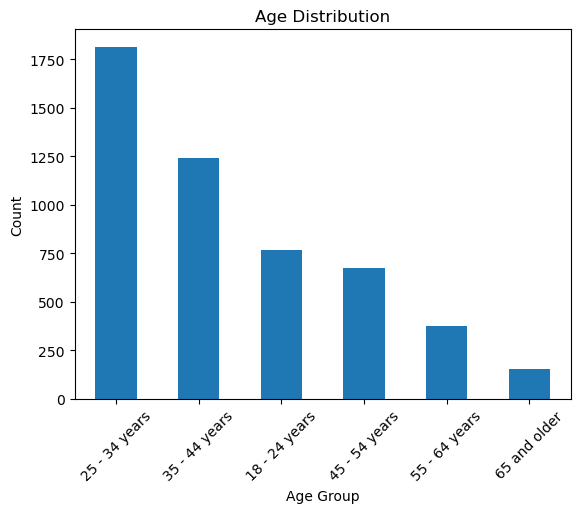

In [13]:
plt.figure()
users['Age'].value_counts().plot(kind='bar')
plt.title('Age Distribution')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### 5.2 Gender Distribution - Pie Chart

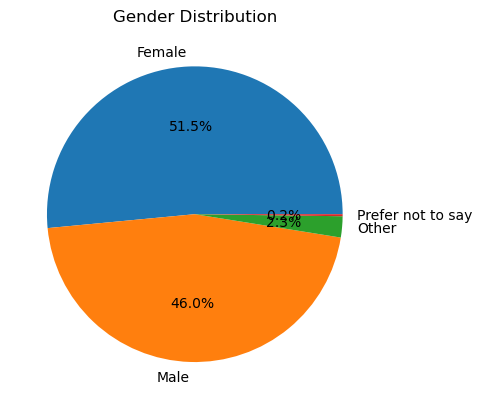

In [15]:
plt.figure()
users['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

### 5.3 Amazon Usage Frequency - Count Plot

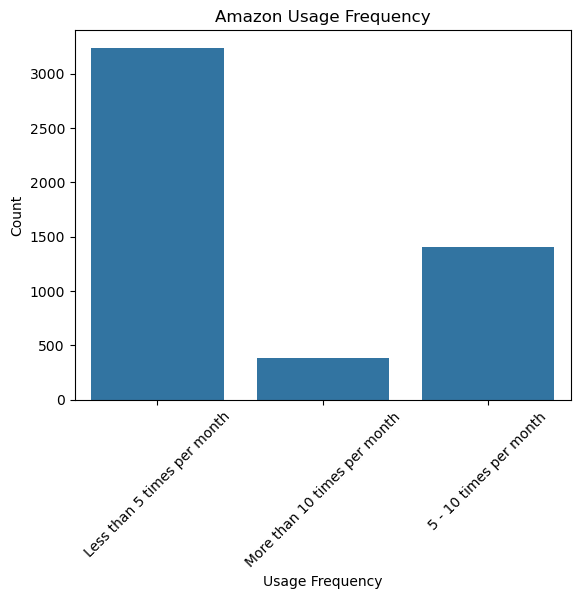

In [17]:
import seaborn as sns
plt.figure()
sns.countplot(data=users, x='Acc Usage')
plt.title('Amazon Usage Frequency')
plt.xlabel('Usage Frequency')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### 5.4 Income vs Education - Heatmap

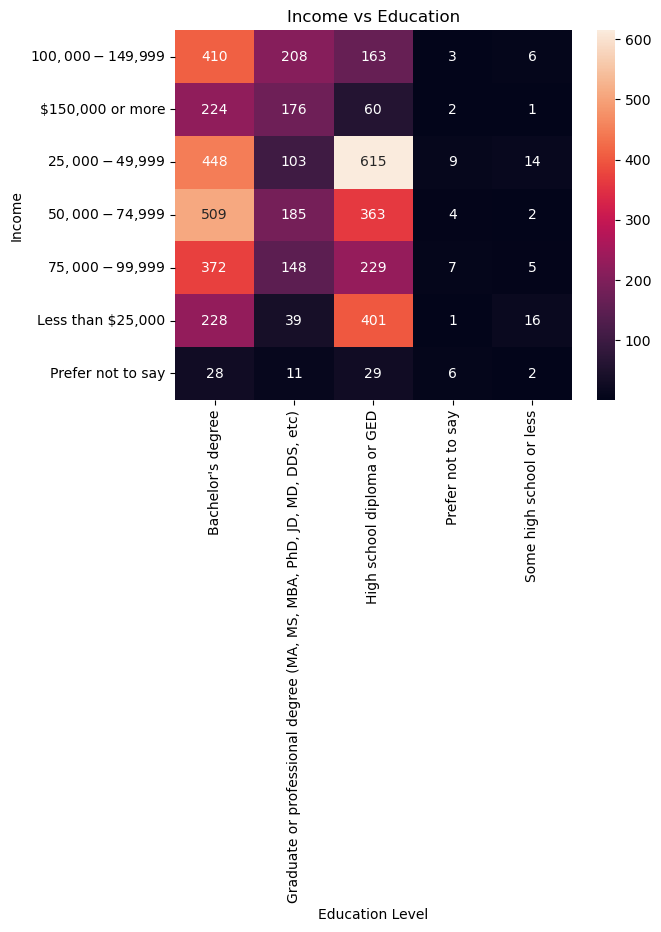

In [18]:
pivot = pd.crosstab(users['Income'], users['Education'])

plt.figure()
sns.heatmap(pivot, annot=True, fmt='d')
plt.title('Income vs Education')
plt.xlabel('Education Level')
plt.ylabel('Income')
plt.show()